In [2]:
import sys
import os

# العودة للمجلد الرئيسي للمشروع
sys.path.append(os.path.abspath('..'))

import networkx as nx
from src.problems.maxcut import MaxCutProblem
from src.algorithms.qaoa import QAOACircuitBuilder

print("SUCCESS: Ready to run QAOA!")

SUCCESS: Ready to run QAOA!


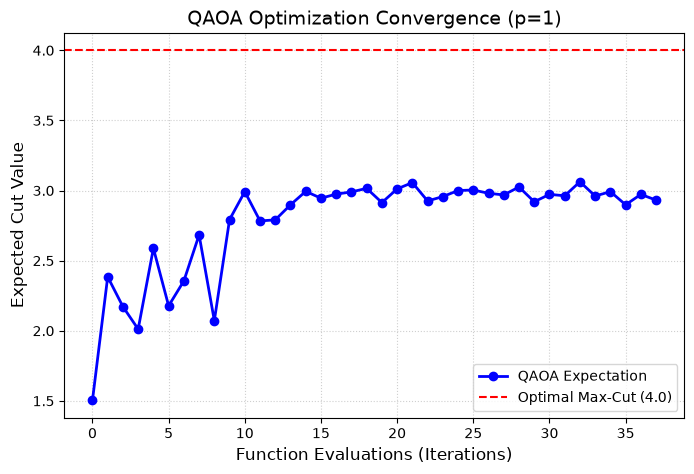

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from src.problems.maxcut import MaxCutProblem
from src.algorithms.qaoa import QAOACircuitBuilder
from src.optimizers.classical import QAOAOptimizer

# 1. Setup Graph & QAOA
G = nx.cycle_graph(4)
problem = MaxCutProblem(G)
p = 1
builder = QAOACircuitBuilder(G, p=p)
circuit, gammas, betas = builder.build_circuit()

# 2. Run Optimization
optimizer = QAOAOptimizer(problem, circuit, gammas, betas)
np.random.seed(42)
initial_params = np.random.uniform(0, np.pi, 2 * p)

opt_params, max_exp, history = optimizer.optimize(initial_params, method='COBYLA')

# 3. Plot Convergence Curve
plt.figure(figsize=(8, 5))
plt.plot(history, marker='o', color='b', linewidth=2, label='QAOA Expectation')
plt.axhline(y=4.0, color='r', linestyle='--', label='Optimal Max-Cut (4.0)')
plt.title('QAOA Optimization Convergence (p=1)', fontsize=14)
plt.xlabel('Function Evaluations (Iterations)', fontsize=12)
plt.ylabel('Expected Cut Value', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()